# Apartment Price Prediction – Project
**Task:** Predict rental prices for apartments in the canton of Zurich  
**Approach:** Two model iterations, documented and compared using 5-fold cross-validation

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from math import radians, cos, sin, asin, sqrt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import root_mean_squared_error

## Load & Clean Data

In [2]:
df = pd.read_csv('apartments_data_enriched_with_new_features.csv', sep=',', encoding='utf-8')

# Remove missing values and duplicates
df = df.dropna()
df = df.drop_duplicates()

# Remove extreme prices
df = df[(df['price'] >= 750) & (df['price'] <= 8000)]

print('Shape after cleaning:', df.shape)
df.head(3)

Shape after cleaning: (804, 45)


,Unnamed: 0,bfs_number,rooms,area,price,postalcode,address,town,description_raw,bfs_name,...,Kreis 10,Kreis 4,Kreis 1,Kreis 9,Kreis 5,Kreis 7,Kreis 3,Kreis 2,Kreis 8,zurich_city
0,0,118,3.0,49,1441,8630,"Neuhusstrasse 6, 8630 Rüti ZH",Rüti ZH,Ein tolles LOFT mit SEESICHT und EXKLUSIVEM De...,Rüti (ZH),...,0,0,0,0,0,0,0,0,0,0
1,1,118,3.0,111,2600,8630,"Widacherstrasse 5, 8630 Rüti ZH",Rüti ZH,«3 Zimmer-Maisonette-Wohnung»,Rüti (ZH),...,0,0,0,0,0,0,0,0,0,0
2,2,118,3.0,58,1490,8630,"Widenweg 14, 8630 Rüti ZH",Rüti ZH,"«Ruhig & Grün , Genau was Sie suchen !»",Rüti (ZH),...,0,0,0,0,0,0,0,0,0,0


## Helper: Model Performance (5-fold CV)

In [3]:
def model_performance(model, features, df, label=''):
    """Run 5-fold cross-validation and print RMSE + R² results."""
    X, y = df[features], df['price']
    rmse_scores = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=5)
    r2_scores   = cross_val_score(model, X, y, scoring='r2', cv=5)
    mean_rmse = round(abs(np.mean(rmse_scores)), 1)
    mean_r2   = round(np.mean(r2_scores), 4)
    print(f'[{label}]')
    print(f'  CV RMSE scores : {np.round(rmse_scores, 1)}')
    print(f'  Mean RMSE      : {mean_rmse} CHF')
    print(f'  Mean R²        : {mean_r2}')
    print()
    return mean_rmse, mean_r2

---
# Iteration 1 – Baseline
**Objective:** Establish a baseline using core features from the weekly exercises.  
**Models:** Linear Regression, Random Forest (default settings)  
**Features:** 13 features from weeks 1–2 (no new feature, no `avg_price_postal_rooms_area`)

### Preprocessing – Iteration 1
- Removed rows with missing values (`dropna`)
- Removed duplicate rows
- Removed price outliers below 750 CHF and above 8000 CHF
- Selected 13 engineered features from weeks 1–2
- No feature scaling (not needed for tree-based models; used as unscaled baseline for Linear Regression)

In [4]:
features_iter1 = [
    'rooms', 'area', 'pop', 'pop_dens', 'frg_pct', 'emp', 'tax_income',
    'room_per_m2', 'luxurious', 'temporary', 'furnished',
    'area_cat_ecoded', 'zurich_city'
]
print('Number of features:', len(features_iter1))

Number of features: 13


In [5]:
lr_rmse_1, lr_r2_1 = model_performance(
    LinearRegression(), features_iter1, df,
    label='Iteration 1 – Linear Regression'
)

[Iteration 1 – Linear Regression]
  CV RMSE scores : [-975.2 -806.1 -606.2 -558.7 -536.1]
  Mean RMSE      : 696.4 CHF
  Mean R²        : 0.4947



In [6]:
rf_rmse_1, rf_r2_1 = model_performance(
    RandomForestRegressor(n_estimators=100, random_state=42),
    features_iter1, df,
    label='Iteration 1 – Random Forest (n_estimators=100)'
)

[Iteration 1 – Random Forest (n_estimators=100)]
  CV RMSE scores : [-983.5 -925.3 -476.9 -592.1 -519.6]
  Mean RMSE      : 699.5 CHF
  Mean R²        : 0.5184



### Iteration 1 – Conclusion
Random Forest outperforms Linear Regression but likely overfits (train score >> CV score).  
**Next:** Add `avg_price_postal_rooms_area`, the new `dist_to_zhb` feature, and tune hyperparameters.

---
# Iteration 2 – New Feature + Tuned Models
**Objective:** Improve performance with a new feature and better hyperparameters.  
**Models:** Tuned Random Forest, MLP Neural Network  
**New feature:** `dist_to_zhb` — distance to Zürich Hauptbahnhof in km (calculated from lat/lon)

### Preprocessing – Iteration 2
- All steps from Iteration 1 retained
- **New:** `dist_to_zhb` — haversine distance (km) from each apartment to Zürich HB (47.3782°N, 8.5403°E)
- **Added:** `avg_price_postal_rooms_area` — mean rent for same postal code + room count + area bracket
- Applied `StandardScaler` inside a Pipeline for the MLP model only
- Total features: 15

In [7]:
def haversine_km(lat1, lon1, lat2=47.3782, lon2=8.5403):
    """Haversine distance in km between (lat1, lon1) and Zürich HB."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * asin(sqrt(a))

df['dist_to_zhb'] = df.apply(lambda row: haversine_km(row['lat'], row['lon']), axis=1)

print('Sample distances to Zürich HB:')
print(df[['town', 'dist_to_zhb']].drop_duplicates('town').sort_values('dist_to_zhb').head(10))

Sample distances to Zürich HB:
                     town  dist_to_zhb
10                 Zürich     1.198910
619              Zollikon     4.762090
448               Opfikon     4.816268
707             Dübendorf     5.331371
445   Glattpark (Opfikon)     5.470728
797       Uitikon Waldegg     5.749394
756           Wallisellen     5.771569
622          Zollikerberg     5.993347
533           Pfaffhausen     6.362868
446            Glattbrugg     6.601867


In [8]:
df['avg_price_postal_rooms_area'] = df.groupby(['postalcode', 'rooms'])['price'].transform('mean')


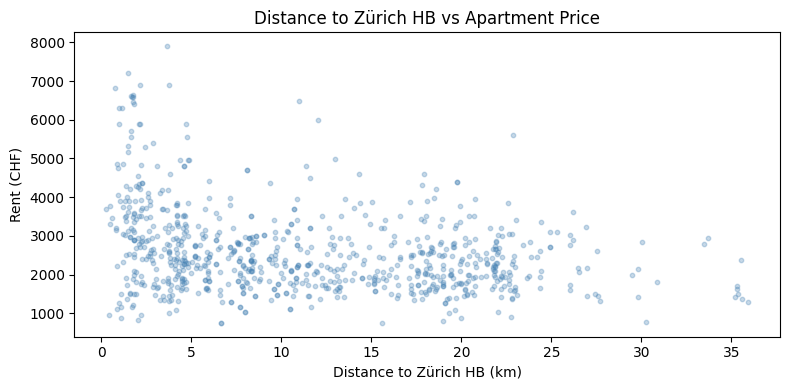

Correlation of dist_to_zhb with price: -0.2941


In [9]:
plt.figure(figsize=(8, 4))
plt.scatter(df['dist_to_zhb'], df['price'], alpha=0.3, color='steelblue', s=10)
plt.xlabel('Distance to Zürich HB (km)')
plt.ylabel('Rent (CHF)')
plt.title('Distance to Zürich HB vs Apartment Price')
plt.tight_layout()
plt.show()

corr = df['dist_to_zhb'].corr(df['price'])
print(f'Correlation of dist_to_zhb with price: {corr:.4f}')

In [10]:
features_iter2 = [
    'rooms', 'area', 'pop', 'pop_dens', 'frg_pct', 'emp', 'tax_income',
    'room_per_m2', 'luxurious', 'temporary', 'furnished',
    'area_cat_ecoded', 'zurich_city',
    'avg_price_postal_rooms_area',
    'dist_to_zhb'
]
print('Number of features:', len(features_iter2))

Number of features: 15


In [11]:
rf_rmse_2, rf_r2_2 = model_performance(
    RandomForestRegressor(n_estimators=500, max_depth=15, random_state=42),
    features_iter2, df,
    label='Iteration 2 – Random Forest (n_estimators=500, max_depth=15)'
)

[Iteration 2 – Random Forest (n_estimators=500, max_depth=15)]
  CV RMSE scores : [-629.5 -521.8 -362.  -325.2 -244.1]
  Mean RMSE      : 416.5 CHF
  Mean R²        : 0.8244



In [12]:
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                         solver='adam', max_iter=500, random_state=42))
])

mlp_rmse_2, mlp_r2_2 = model_performance(
    mlp_pipeline, features_iter2, df,
    label='Iteration 2 – MLP (layers=64,32, relu, adam, 500 iter)'
)

[Iteration 2 – MLP (layers=64,32, relu, adam, 500 iter)]
  CV RMSE scores : [-731.1 -541.  -866.3 -473.2 -474.7]
  Mean RMSE      : 617.3 CHF
  Mean R²        : 0.4856



---
# Full Comparison – All Iterations

In [13]:
results = {
    'Iteration 1 – Linear Regression':        {'RMSE': lr_rmse_1,  'R2': lr_r2_1},
    'Iteration 1 – Random Forest':            {'RMSE': rf_rmse_1,  'R2': rf_r2_1},
    'Iteration 2 – Random Forest (tuned)':    {'RMSE': rf_rmse_2,  'R2': rf_r2_2},
    'Iteration 2 – MLP Neural Network':       {'RMSE': mlp_rmse_2, 'R2': mlp_r2_2},
}

df_results = pd.DataFrame(results).T
df_results.columns = ['CV Mean RMSE (CHF)', 'CV Mean R²']
print(df_results.to_string())

                                     CV Mean RMSE (CHF)  CV Mean R²
Iteration 1 – Linear Regression                   696.4      0.4947
Iteration 1 – Random Forest                       699.5      0.5184
Iteration 2 – Random Forest (tuned)               416.5      0.8244
Iteration 2 – MLP Neural Network                  617.3      0.4856


---
# Final Model – Train on Full Dataset & Save

In [14]:
best_model = RandomForestRegressor(n_estimators=500, max_depth=15, random_state=42)
best_model.fit(df[features_iter2], df['price'])

print('Trained on', len(df), 'apartments')
print('Train R²:', round(best_model.score(df[features_iter2], df['price']), 4))

Trained on 804 apartments
Train R²: 0.9709


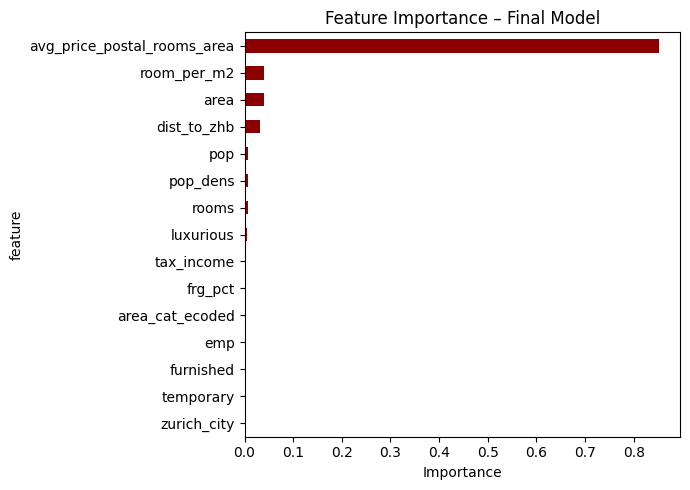

In [15]:
df_fi = pd.DataFrame({
    'feature': features_iter2,
    'importance': best_model.feature_importances_
}).sort_values('importance')

df_fi.plot(kind='barh', x='feature', y='importance',
           color='darkred', figsize=(7, 5), legend=False)
plt.title('Feature Importance – Final Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [16]:
with open('apartment_price_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print('Model saved to apartment_price_model.pkl')
print('Features used:', features_iter2)

Model saved to apartment_price_model.pkl
Features used: ['rooms', 'area', 'pop', 'pop_dens', 'frg_pct', 'emp', 'tax_income', 'room_per_m2', 'luxurious', 'temporary', 'furnished', 'area_cat_ecoded', 'zurich_city', 'avg_price_postal_rooms_area', 'dist_to_zhb']
